# Phân tích và dự đoán chất lượng rượu vang

## 1. Đọc dữ liệu và hiển thị thông số

In [6]:
import pandas as pd
 
df = pd.read_csv('../data/winequality-red.csv')
# display(df.head())
shape = df.shape
dimention = df.ndim
dtypes = df.dtypes
describe = df.describe()

display(df.head())
print('Shape:', shape)
print('Dimention:', dimention)
print('Data Types:\n', dtypes)
# print('Columns:\n', columns)
# print('Info:\n', info)
print('Describe:\n', describe)



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Shape: (1599, 12)
Dimention: 2
Data Types:
 fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object
Describe:
        fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.42000

In [7]:
#Phân phối nhãn và chỉ số thống kê
#phân phối nhãn cột quality
label_distribution = df['quality'].value_counts().sort_index()

#tính các chỉ số thống kê (Max, Min, Mean) 
stats = df.describe().loc[['min', 'max', 'mean']]
print('Label Distribution:\n', label_distribution)
print('Statictical:\n', stats.round(1))

Label Distribution:
 quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64
Statictical:
       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
min             4.6               0.1          0.0             0.9        0.0   
max            15.9               1.6          1.0            15.5        0.6   
mean            8.3               0.5          0.3             2.5        0.1   

      free sulfur dioxide  total sulfur dioxide  density   pH  sulphates  \
min                   1.0                   6.0      1.0  2.7        0.3   
max                  72.0                 289.0      1.0  4.0        2.0   
mean                 15.9                  46.5      1.0  3.3        0.7   

      alcohol  quality  
min       8.4      3.0  
max      14.9      8.0  
mean     10.4      5.6  


In [8]:
#Xuất file csv
stats.to_csv('../data/statictical.csv', index=True)
label_distribution.to_csv('../data/label_distribution.csv', index=True)

## 2. Trực quan hóa dữ liệu

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Tách đặc trưng và nhãn
X = df.drop(columns=['quality'])
y = df['quality']

# 1) Chuẩn hóa (quan trọng trước PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2) Giảm chiều còn 2 thành phần chính
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 3) Tỷ lệ phương sai được giữ lại
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

# 4) Vẽ scatter theo nhãn quality
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D - Wine Quality')
plt.colorbar(scatter, label='Quality')
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

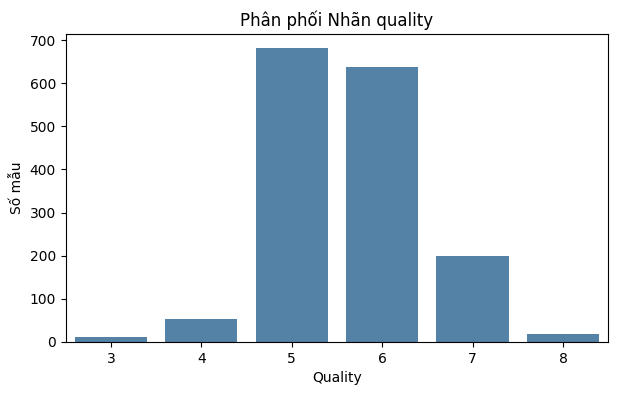

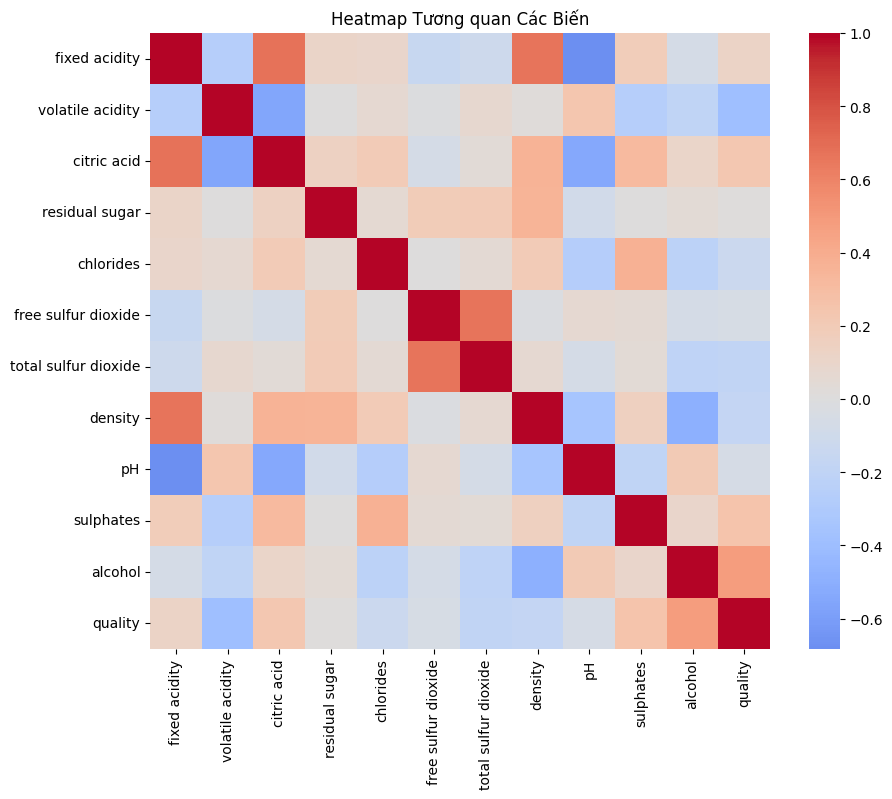

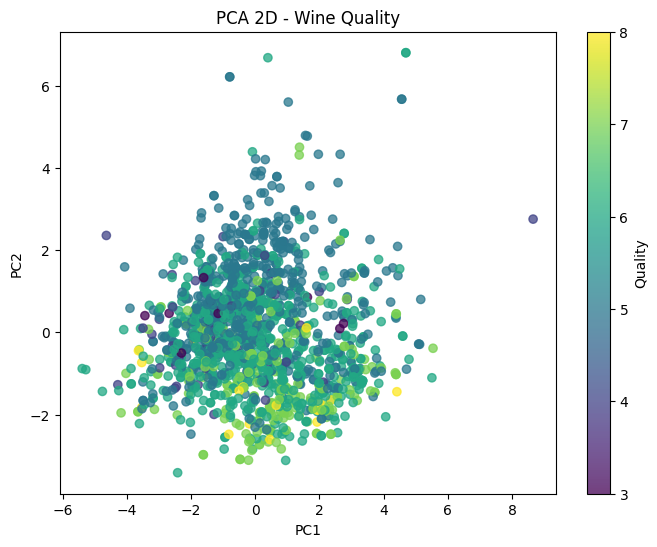

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1) Biểu đồ phân phối quality
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='quality', color='steelblue')
plt.title('Phân phối Nhãn quality')
plt.xlabel('Quality')
plt.ylabel('Số mẫu')
plt.show()

# 2) Heatmap tương quan
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Heatmap Tương quan Các Biến')
plt.show()

# 3) PCA 2D scatter theo nhãn quality
X = df.drop(columns=['quality'])
y = df['quality']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# plt.figure(figsize=(8, 6))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.75)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D - Wine Quality')
plt.colorbar(sc, label='Quality')
plt.show()


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import importlib
import module
importlib.reload(module)
from module import (
    standardize_data,
    train_svm_with_gridsearch,
    evaluate_model,
    build_report,
    save_report_json,
    save_report_csv,
)

# Đọc dữ liệu
df = pd.read_csv("../data/winequality-red.csv")

# Tách đặc trưng/nhãn
X = df.drop(columns=["quality"])
y = df["quality"]

# Chia train/test có stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Chuẩn hóa dữ liệu cho SVM
X_train_scaled, X_test_scaled = standardize_data(X_train, X_test)

# Huấn luyện SVM + Grid Search 10-fold CV
train_result = train_svm_with_gridsearch(X_train_scaled, y_train)

best_model = train_result["best_model"]
best_params = train_result["best_params"]
best_cv_score = train_result["best_cv_score"]

# Đánh giá trên tập test
eval_result = evaluate_model(best_model, X_test_scaled, y_test)
test_f1_score = eval_result["test_f1_weighted"]

# Tạo và lưu báo cáo chuẩn
report = build_report(
    best_params=best_params,
    best_cv_score=best_cv_score,
    test_f1_score=test_f1_score,
    n_train=len(X_train),
    n_test=len(X_test),
    model_name="SVC",
    scoring="f1_weighted",
)

save_report_json(report, "../data/svm_gridsearch_report.json")
save_report_csv(report, "../data/svm_gridsearch_report.csv")

print("Best params:", best_params)
print("Best CV F1-weighted:", best_cv_score)
print("Test F1-weighted:", test_f1_score)

ImportError: cannot import name 'train_svm_with_gridsearch' from 'module' (e:\Winequality_DataMining\notebooks\module.py)

## 3. Huấn luyện và đánh giá mô hình

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split

from module import (
    standardize_data,
    train_svm_with_gridsearch,
    evaluate_model,
    build_report,
    save_report_json,
    save_report_csv,
)

# Đọc dữ liệu
df = pd.read_csv("../data/winequality-red.csv")

# Tách đặc trưng/nhãn
X = df.drop(columns=["quality"])
y = df["quality"]

# Chia train/test có stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Chuẩn hóa dữ liệu cho SVM
X_train_scaled, X_test_scaled = standardize_data(X_train, X_test)

# Huấn luyện SVM + Grid Search 10-fold CV
train_result = train_svm_with_gridsearch(X_train_scaled, y_train)

best_model = train_result["best_model"]
best_params = train_result["best_params"]
best_cv_score = train_result["best_cv_score"]

# Đánh giá trên tập test
eval_result = evaluate_model(best_model, X_test_scaled, y_test)
test_f1_score = eval_result["test_f1_weighted"]

# Tạo và lưu báo cáo chuẩn
report = build_report(
    best_params=best_params,
    best_cv_score=best_cv_score,
    test_f1_score=test_f1_score,
    n_train=len(X_train),
    n_test=len(X_test),
    model_name="SVC",
    scoring="f1_weighted",
)

save_report_json(report, "../data/svm_gridsearch_report.json")
save_report_csv(report, "../data/svm_gridsearch_report.csv")

print("Best params:", best_params)
print("Best CV F1-weighted:", best_cv_score)
print("Test F1-weighted:", test_f1_score)

ImportError: cannot import name 'train_svm_with_gridsearch' from 'module' (e:\Winequality_DataMining\notebooks\module.py)

## 4. Gom cụm dữ liệu

In [ ]:
# Code KMeans và DBSCAN sẽ được viết ở đây

## 5. Kết luận